<a id='top'></a>

# CSCI3022 S23



# Homework 2: Measures of Centrality and Dispersion; Visualizing Data

## Due Monday, January 30th at 11:59pm to Gradescope
***

**Name**: Dominic Galgano

***

***
### Collaboration Policy

While completing the assignment you are not allowed to consult any source other than the course textbooks/online reference links provided on Canvas, your own class notes, and/or the posted lecture slides/in-class Jupyter notebooks.   You may discuss questions you have with your classmates or on Piazza or in office hours, but all work you submit must be your own, which means when writing up your solutions or code, you MUST do it entirely by yourself. 

You should be able to easily reproduce from scratch and explain a solution that was your own when asked in office hours by a TA/Instructor or on a quiz/exam without referencing your notes/book/HW.   


**Do not search/ask for a solution online**: You may not actively search for a solution to the problems below from the internet. This includes posting to or using sources like ChatGPT, StackExchange, Reddit, Chegg, CourseHero, etc.  

**We are here to help!  Visit HW Hours and/or post questions on Piazza!**


Copying/consulting from the solution of another classmate or an online solution (or providing a classmate your solution) constitutes a **violation of the course's collaboration policy and the honor code and will result in an F in the course and a trip to the honor council**.   






### Instructions for Submitting in Correct Format 

You must submit a PDF of this Juptyer notebook to Gradescope by the deadline listed above.  Submissions that are not a PDF or that are not submitted to Gradescope will not be counted for credit.  

$\color{red}{\text{Before submitting your PDF, make sure that your LaTeX has rendered correctly in your PDF.}}$
$\color{red}{\text{Any of your solutions with incorrectly rendered or incompletely rendered LaTeX will be given 0 points.}}$ 

- There are several ways to quickly make a .pdf out of this notebook for Gradescope submission.  
 
 - If you are running Juptyer locally on your computer: 
 
     - Option1 : Select Kernel->Restart & Run All. Use File ->  Print Preview, and then Right-Click -> Print using your default browser and "Print to PDF"
 
     - Option 2: Select Kernel->Restart & Run All. Use File -> Download as PDF via LaTeX.  This will require your system path find a working install of a TeX compiler
 
 - If you are running using CSEL: 
 
     - Option1 :  Go to File ->Save & Export Notebook As-> HTML.  Then open the HTML, and then Right-Click -> Print and select "Print to PDF".  
     - Option2 :  Go to File ->Download. Then use this converter https://htmtopdf.herokuapp.com/ipynbviewer/ to convert ipynb to pdf.
 
### Notes
- For full points you must correctly match your questions to the respective Gradescope problem, and include clear comments in your code.   Please note that any LaTeX that is not correctly rendered in your submitted PDF will result in a 0 on the entire problem(s) that involves the unrendered LaTeX. 
- For any question that asks you to calculate something, you **must show all work and justify your answers to receive credit**. Sparse or nonexistent work will receive sparse or nonexistent credit. 
- Any relevant data sets are available on Canvas. 
- LaTeX Tips:  Here is a [reference guide] (https://math.meta.stackexchange.com/questions/5020/mathjax-basic-tutorial-and-quick-reference).  **All** of your written commentary, justifications and mathematical work should be in Markdown.  I also recommend the [wikibook](https://en.wikibooks.org/wiki/LaTeX) for LaTex.
- Because you can technically evaluate notebook cells is a non-linear order, it's a good idea to do **Kernel $\rightarrow$ Restart & Run All** as a check before submitting your solutions.  
- It is **bad form** to make your reader interpret numerical output from your code.  If a question asks you to compute some value from the data you should show your code output **AND** write a summary of the results in Markdown directly below your code. 

- There is *not a prescribed API* for these problems.  You may answer coding questions with whatever syntax or object typing you deem fit.  Your evaluation will primarily live in the clarity of how well you present your final results, so don't skip over any interpretations!  Your code should still be commented and readable to ensure you followed the given course algorithm.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline


## (14 pts) Problem 1: Computation (Streaming Means)
***

Data science is often divided into two categories: questions of *what* the best value might be to represent a data problem, and questions of *how* to compute that data value.  Prior lectures should tell you that computing the mean is valuable!  But *how* do we compute the mean?

Let $x_1, x_2, \ldots, x_n$ be $n$ observations of a variable of interest.  Recall that the sample mean $\bar{x}_n$ and sample variance $s^2_n$ are given by 
<a id='eq1'></a>
$$
\bar{x}_n = \frac{1}{n}\sum_{k=1}^n x_k \quad \textrm{and} \quad s^2_n = \frac{1}{n-1}\sum_{k=1}^n \left( x_k - \bar{x}_n\right)^2 \qquad \tag{Equation 1}
$$

**Part A**: (1 pt)

How many computations - floating point operations: addition, subtraction, multiplication, division each count as 1 operation - are required to compute the **mean** of a data set with $n$ observations? (assume $n>1$).  Explain your answer.


## Answer 1A
$n$ computation operations are necessary to compute the mean

First we must sum together all the values in the sample set which means we must do the addition operation $n - 1$ times, since
it will take the same number of addition operations as there are values, except for the first two values added together will
only use one addition operation meaning in total addition will need to be preformed $n - 1$ times.

Second we must use $1$ division operation on the sum to find the mean meaning we used $(n - 1) + 1$ operations which reduces to
$n$ operations

**Part B**: (2 pts)  
i).  Write a function `my_sample_mean` that takes as its input a numpy array and returns the mean of that numpy array using the formulas from class ([Equation 1](#eq1)). 

ii).  Write another function `my_sample_var` that takes as its input a numpy array and returns the variance of that numpy array, again using the formulas from class ([Equation 1](#eq1)). 

You may **not** use any built-in sample mean or variance functions.  Hint:  Try to do this without using any `for` loops.

In [2]:
def my_sample_mean(numpy_array):
    mean = 0
    
    #To prevent an undefined error checks to see if array contains values
    if(numpy_array.size > 0):
        #Calculates mean of the values in array by summing them and then dividing by the total number of values
        mean = numpy_array.sum() / numpy_array.size
        
    return mean

def my_sample_var(numpy_array):
    var = 0
    if(numpy_array.size > 1):
        #Pulls in mean using my_sample_mean function
        mean = my_sample_mean(numpy_array)
        
        #Subtracts the mean from all values and them squares them
        numpy_array = numpy_array - mean
        numpy_array = np.square(numpy_array)
        
        #Calculates the variance 
        var = np.sum(numpy_array) / (numpy_array.size - 1)
        
    return var


**Part C**: (1 pt)  Use your functions from Part B to compute the sample mean and sample variance of the following array, which contains the minutes late that the BuffBus is running on Friday afternoon:

`bus = [4, 10, 0, 312, 22, 39, 81, 19, 8, 60, 1,3,80, 42,12,1]`

In [3]:
#Test data to check functions
bus = np.array([4, 10, 0, 312, 22, 39, 81, 19, 8, 60, 1,3,80, 42, 12, 1])

#Outputs mean function tested on bus array and the expected mean
print("The mean of the test data is", format(my_sample_mean(bus)))
print("The mean of the test data should be", format(bus.mean()))
print()
#Outputs variance function tested on bus and the expected variance
print("The variance of the test data is", format(my_sample_var(bus)))
print("The variance of the test data should be", format(bus.var(ddof=1)))

The mean of the test data is 43.375
The mean of the test data should be 43.375

The variance of the test data is 5884.516666666666
The variance of the test data should be 5884.516666666666


**Part D**: (1 pt)

Now suppose our data is streaming- we slowly add observations one at a time, instead of seeing the entire data set at once. We are still interested in the mean.

Suppose we inefficiently recalculate the mean by brute force after each new observation is added to our data set. In this brute force calculation we do not save any information from previous mean calculations (for example, we would start by computing the mean of first two points, then when a 3rd data point is added we would recompute the mean of the first three datapoints (without using any information we gathered when calculating the mean of the first 2 data points), and so forth until we had compiled all $n$ means). 

How many floating point operations are spent computing (and re-computing) the $n$ means of a streaming data set of size $n$ in this inefficient brute force manner?  (Note that the mean of the first data point is just itself, so no floating-point computations are required to compute the first mean). 

Use formulas for summations from Calculus 2 (https://tutorial.math.lamar.edu/classes/calci/summationnotation.aspx)  to fully simplify your answer in closed form (i.e. without using sigma notation) in terms of $n$: 

## Answer 1D
As discussed in part A the number of computational operations required to compute a mean of $n$-elements is $n$ operations. Assuming the no floating-point computations are required to compute the first mean, then it will take $(n - 1) * n $ or $ n^2 - n$ operations to compute mean using this brute force method.

First we use the reasoning from part A to determined each recalculation requires $n$ operations

Second we multiple the number of operations required to compute one mean by the size of the entire list of elements, which is length $n - 1$ in this case. This results in $n * (n - 1)$ operations or $n^2 - n$ operations total

We should be convinced that streaming a mean costs a lot more computer time than just computing once!

In this problem we explore a smarter method for such an _online_ computation of the mean.  

The following relation holds between the mean of the first $n-1$ observations and the mean of all $n$ observations: 


<a id='eq2'></a>
$$
\bar{x}_n = \bar{x}_{n-1} + \frac{x_n - \bar{x}_{n-1}}{n}
\tag{Equation 2}
$$


**Part E**  (2 pts)
Prove mathematically why Equation 2 is true using the definition(s) of $\bar{x}_n$ and $\bar{x}_{n-1}$.



## Answer 1E
Assuming $\bar{x}_n = \frac{1}{n}\sum_{k=1}^n x_k$ and $\bar{x}_{n-1} = (\frac{1}{n}\sum_{k=1}^n x_k) - \frac{x_n}{n}$ we can substitue in the equation on the left side and reduce

$\implies \frac{1}{n}\sum_{k=1}^n x_k = \bar{x}_{n-1} + \frac{x_n - \bar{x}_{n-1}}{n}$

$\implies \frac1n\sum_{k=1}^{n-1}x_k + \frac{x_n}{n} = \bar{x}_{n-1} + \frac{x_n - \bar{x}_{n-1}}{n}$

$\implies \sum_{k=1}^{n-1}x_k + x_n = n\bar{x}_{n-1} + x_n - \bar{x}_{n-1}$

$\implies \sum_{k=1}^{n-1}x_k = n\bar{x}_{n-1} - \bar{x}_{n-1}$

$\implies \sum_{k=1}^{n-1}x_k = \bar{x}_{n-1}(n - 1)$

$\implies \frac{1}{n - 1}\sum_{k=1}^{n-1}x_k = \bar{x}_{n-1} = (\frac{1}{n}\sum_{k=1}^n x_k) - \frac{x_n}{n}$

The initial equation is true because when plugging in the equation for the mean $\bar{x}_n$ we are able to reduce the equation down to another true statement which says the mean value of the set minus the last value or $\bar{x}_{n-1}$ equals the sum of all elements except for the last one divided by the total number of elements minus $1$ or $\frac{1}{n - 1}\sum_{k=1}^{n-1}x_k$. This makes sense because if you were to take the mean of a data set one element smaller you would have to subtract $1$ from $n$ where ever it occurred to produce the right result.

**Part F**: (2 pts)  Implement a third function called `update_mean` that implements Equation 2. Note that this function will need to take as its input three things: $x_n$, $\bar{x}_{n-1}$ and $n$, and returns $\bar{x}_{n}$. A function header and return statement are provided for you. 



In [4]:
def update_mean(prev_mean, xn, n):
    new_mean = prev_mean + ((xn - prev_mean) / n)
    return(new_mean)

**Part G** (2 pts) Use the function you created in Part F to compute the values that you get from finding the mean of the first two buff buses' lateness, then the mean first three buff buses' lateness, and so on up to all of the `bus` data points from **Part C**. Store your streaming bus means in a numpy array called `buffbus_bad_means`.  Report all 16 estimates in `buffbus_bad_means`.

In [5]:
#Initialize values to use update_mean
last_mean = bus[0]
buffbus_bad_means = np.zeros(shape = bus.size)
n = 0

#Iterates through bus times and calculates the new mean using the update_mean function
for x in bus[1:]:
    #Prints the new mean each time when it is updated
    buffbus_bad_means[n] = last_mean
    print("For n equals", n, "the new mean is", buffbus_bad_means[n].round(3))
    #Updates n value
    n += 1
    
    #Updates mean using prev. mean, xn, and n
    last_mean = update_mean(last_mean, x, n + 1)

#Prints the final value because it is left out of the loop(I chose this over hard coding it before the loop)
buffbus_bad_means[n] = last_mean
print("For n equals", n, "the new mean is", buffbus_bad_means[n].round(3))

#Prints the expected final mean for testing
print()
print("Expected final mean", format(bus.mean()))

For n equals 0 the new mean is 4.0
For n equals 1 the new mean is 7.0
For n equals 2 the new mean is 4.667
For n equals 3 the new mean is 81.5
For n equals 4 the new mean is 69.6
For n equals 5 the new mean is 64.5
For n equals 6 the new mean is 66.857
For n equals 7 the new mean is 60.875
For n equals 8 the new mean is 55.0
For n equals 9 the new mean is 55.5
For n equals 10 the new mean is 50.545
For n equals 11 the new mean is 46.583
For n equals 12 the new mean is 49.154
For n equals 13 the new mean is 48.643
For n equals 14 the new mean is 46.2
For n equals 15 the new mean is 43.375

Expected final mean 43.375


To ensure your function complies with the given API, run this small test, where we suppose we have a mean of $\bar{x}_n = 1$ with the first $2$ data points (`prev_mean`), and we update this with the 3rd ($n=3$) data point which is $x_3=2$:

In [6]:
assert update_mean(1,2,3)==4/3, "Warning: function seems broken."

**Part H**: (1 pt)

How many floating point operations were spent computing the 16 means in your code in part G? (Again you can assume that no floating point operations are required for the first mean).  Is this truly better than the uninformed approach from part D?

## Answer 1H

In the update_mean function $3$ floating point operations occur: first addition, then subtraction, and thrid divison. Because we did not need to calculate the initial mean therefore we only did $3 * (n - 1)$ operations. Comparing the results from part D, $3n - 3$ or an $O(n)$ runtime is much more efficient than the brute force calculations of $n^2 - n$ with a runtime of $O(n^2)$

**Part I:** (2 pts)
A similar result to the formula preceding part E holds for variance.  In particular, we can write that:

$$
\displaystyle s^2 = \frac{\sum_{i=1}^n (x_i-\bar{x})^2}{n-1} = \frac{1}{n(n-1)} \left(n \cdot \sum_{i=1}^n x_i^2 - \left(\sum_{i=1}^n x_i \right)^2 \right)
$$

Describe in **words** and/or **psuedocode** how you might adapt the function you made in part **F** to perform running calculations of both variance and mean.  Be very clear as to what the input/instantiation arguments would be as well as what the output arguments would be in addition to any intermediate calculations.

Using this formula, my function take in the original parameters of $\bar{x}_{n-1}, x_n, $ and $n$ and use them to calculate the new mean in the same way as in the update_mean function. Additionally it would take in the array of values the variance was being calculated on and then output an integer representing the variance. The code would look like:

def update_var(prev_mean, xn, n, data):

    new_mean = prev_mean + ((xn - prev_mean) / n)

    new_var = (1 / (n**2 - n)) * (n * np.sum(data.square) - (n * new_mean)**2
    
    return(new_var)
    
First I would calculate the new mean using the same methods as in the update_mean so I could use it to calculate the second sum quickly. Next I would divide the mean by $n$ to get the second sum faster. Finally I would compute the remaining values using numpy array functions.


# Problem 2  (13 pts):  Data Visualization; Means & Variances
***

For Problem 2 we are looking at the data from a study investigating school childrens' intelligence. The data consists of a random sample of 1500 participants and some of their data.

Import the csv file, "foot_smart.csv".  Create a dataframe called `dfFootIQ` and take a look at it.

In [7]:
dfFootIQ = pd.read_csv("foot_smart.csv")


# Description of this data Set

This is a data set of 1500 participants. The participants are all children from 7 different schools. 

***foot_length:*** This is the length of the students foot in inches.

***shoe_size:*** This is the size of the shoe worn by the student.

***sex:*** This is the sex of the student: 0 female, 1 male.

***IQ:*** This is a measure of intelligence as measured on a standard exam, scaled from 0 to 35.

***US_section:*** This is the section of the U.S. that the student comes from.

***city_size:*** This is the approximate size of the city (in thousands) from which the student came from.

***Part a] (1 pt) Clean the data***

Notice that `city_size` has data entered as '100K' for 100,000 and 1M for 1,000,000.

Clean this column so that it holds integers such as 100000 and 1000000 instead of 100K and 1M. 

In [8]:

def clean_city_val(str_val):
    #Strip the whitespace
    str_val = str_val.strip()
    num_val = 0
    
    #Check to see if there is a string to convert
    if(len(str_val) > 0):
        if("K" in str_val):
            str_val = str_val.replace('K',"000")

        if("M" in str_val):
            str_val = str_val.replace('M',"000000")

        num_val = int(str_val)
        
    return num_val

dfFootIQ["city_size"] = dfFootIQ["city_size"].apply(clean_city_val)
print(dfFootIQ)

      foot_length  shoe_size  sex    IQ US_section  city_size
0            7.96          8    0  23.8       West     500000
1            6.76          7    0  21.3       West     500000
2            6.96          7    1  22.2       East     500000
3            7.86          8    1  25.3       East     100000
4            8.17          9    0  23.9       East     100000
...           ...        ...  ...   ...        ...        ...
1495         6.89          7    0  22.9      South       1000
1496         6.03          7    0  18.8      North       1000
1497         8.83          9    1  26.0      North    1000000
1498         7.73          8    0  23.6      North     100000
1499         4.94          5    1  16.9       West     100000

[1500 rows x 6 columns]


***Part b]*** Suppose we were to make a scatterplot for foot length and city size (`foot_length` and `city_size`).



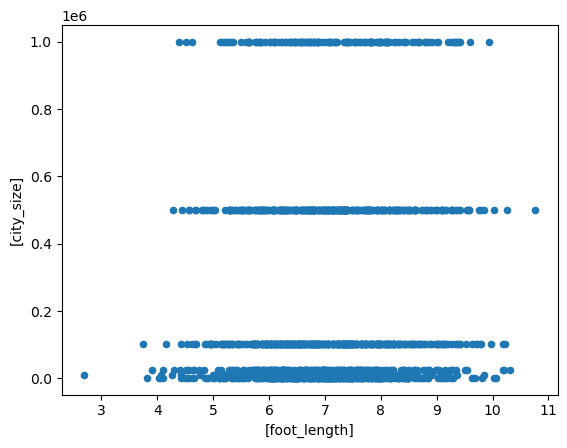

In [9]:
# Uncomment the code below and run it.

ax1 = dfFootIQ.plot.scatter(x=['foot_length'], y=['city_size'])

***Note (i)*** The scatter plot has discrete values on the y-axis which makes the 'scatter plot' look like lines.

***Note (ii)*** There is no discernible pattern. The city's of various sizes (on the y-axis) contain students with shoe sizes (on the x-axis) all across the shoe-size spectrum which means students of a particular shoe size do not tend to congregate in citys  of a particular size.

This seems to be common sense; for instance, there is no reason why every student of shoe size 7 would come from a city of size 500,000.

***Make two more scatterplots:***

   i] ***(0.5 points)*** A scatterplot for shoe_size and IQ

   ii] ***(0.5 points)*** A scatterplot for foot_length and IQ

iii] ***(1 point)*** Explain your findings. Either explain why no pattern is found, or if you detect a pattern, then explain why such a pattern exists between shoe size and intelligence.

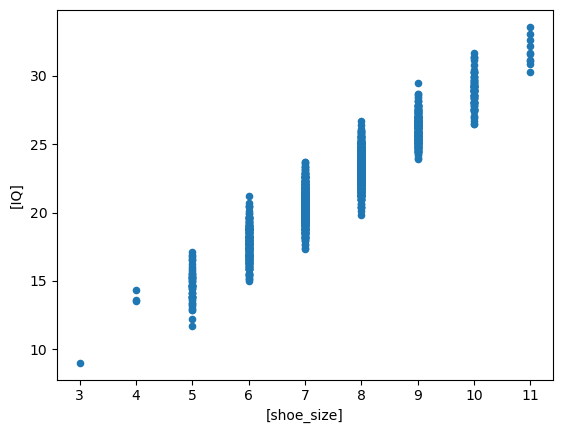

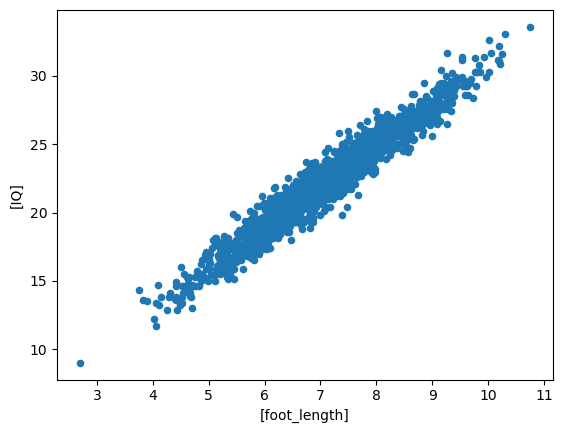

In [10]:
# Code your scatterplots for Part B here
ax2 = dfFootIQ.plot.scatter(x=['shoe_size'], y=['IQ'])

ax3 = dfFootIQ.plot.scatter(x=['foot_length'], y=['IQ'])

The pattern in both scatter plots appears to suggest the larger a students shoe size or foot size the greater their IQ. This is likely due to the fact that as the data is taken from schools, the larger the shoe size the older the student is. Since they are older it is likely they are in a higher grade level and therefore have had more education, allowing to score higher on the IQ test

***Part c]*** 
We're interested in investigating how the mean changes if you add or multiply each of the data points by a constant.  

i).(0.5 pts)  Find the mean shoe size for the dfFootIQ data (you CAN use built-in functions to do this).


In [11]:
print("The mean shoe size of students surveyed is", dfFootIQ['shoe_size'].mean())

The mean shoe size of students surveyed is 7.556666666666667


ii). (1 pt) In class, we proved what will happen to the mean if we add any constant $a$ to each data point.  First, explain what the new mean should be (in terms of $a$) based on what we derived in class.  

The new mean should be $\bar{x} + a$ because if we add $a$ to every value in the set we have $\frac1n \sum^n_{i=0}(x_i + a)$

Since this is a sum we can split it around the $+$ into two summations $\frac1n \sum^n_{i=0}x_i + \frac1n\sum^n_{i=0}a$

Next we can reduce it down to $\frac1n \sum^n_{i=0}x_i + \frac1n a * n$ because $\sum^n_{i=0} c = cn$

Reducing even further we get $\frac1n \sum^n_{i=0}x_i + a$ and since $\frac1n \sum^n_{i=0}x_i$ is the definition of the mean
we get $\bar{x} + a$

 iii). (1 pt)  Then show this via code for $a=2$, by actually adding 2 to each shoe size data point in dfFootIQ and calculating the new mean.  

In [12]:
dfFootIQ['shoe_size'] = dfFootIQ['shoe_size'].apply(lambda a : a + 2)
print("The new mean is", dfFootIQ['shoe_size'].mean(), "when adding 2 to the each element")

The new mean is 9.556666666666667 when adding 2 to the each element


iv). (1 pt)  What if we multiply each term by a constant $c$?  Prove mathematically what the new mean will be (in terms of $c$).  Use the definition of $\bar{x}_n$ from ([Equation 1](#eq1)).


Multiplying each element by a constant $c$ is the same as $\bar{x} * c$. This can we determined by using the equation $\bar{x}_n = \frac{1}{n}\sum_{k=1}^n c * x_k$.

Since all values being summed are being multiplied by the same constant we can pull out the constant resulting in $\frac{c}{n}\sum_{k=1}^n x_k$

After carrying out the summation and dividing by $n$ we are left with $c * \bar{x}_n$

v). (1 pt)  Then show this via code for $c=3$, by actually multiplying each shoe size data point in dfFootIQ by $3$ and calculating the new mean.  

In [13]:
dfFootIQ['shoe_size'] = dfFootIQ['shoe_size'].apply(lambda c : c * 3)
print("The new mean is", dfFootIQ['shoe_size'].mean(), "when multiplying each element by 3")

The new mean is 28.67 when multiplying each element by 3


***Part d]***
We're interested in investigating how the variance changes if you add or multiply each of the data points by a constant.  

i). (0.5 pt)  Find the sample variance shoe size for the dfFootIQ data (you CAN use built-in functions to do this).


In [14]:
print("The variance in shoe size is", dfFootIQ['shoe_size'].var())

The variance in shoe size is 13.486090727151158


ii). (1 pt)  In class, we proved what will happen to the variance if we add any constant $a$ to each data point.  First, explain what the new variance will be based on what we derived in class.  

The variance will remain unchanged because if all values are being increased by the same amount the mean is increased by they will still be the same distance from it. This can be shown by the use of adding a into the variance formula $\sum_{k=1}^n (x_k + a - (\bar{x_n} + a))^2$

First we distribute the negative to both terms in the second set of paratheses resulting in $\sum_{k=1}^n (x_k + a - \bar{x_n} - a)^2$

Then we cancel the $a$s out with each other leaving the original variance formula $\sum_{k=1}^n (x_k - \bar{x_n})^2$

iii). (1 pt)  Then show this via code for $a=2$, by actually adding 2 to each shoe size data point and calculating the new variance.  

In [15]:
dfFootIQ['shoe_size'] = dfFootIQ['shoe_size'].apply(lambda a : a + 2)
print("The new variance is", dfFootIQ['shoe_size'].var(), "when adding 2 to each element")


The new variance is 13.486090727151158 when adding 2 to each element


iv). (2 pts)  What if we multiply each term by a constant $c$?  Prove mathematically what the new variance will be (in terms of $c$).  Use the definition of $s_n^2$ from ([Equation 1](#eq1)).


The variance will be multiplied by $c^2$ because if we put $c$ into the variance formula we get $\sum_{k=1}^n ((x_k * c) - (\bar{x_n} * c))^2$

Now if we pull out the common factor of $c$ from both terms we get $\sum_{k=1}^n (c * (x_k - \bar{x_n}))^2$

We can the pull $c$ out of the next set of parathese by squaring it resulting in $\sum_{k=1}^n (c)^2 * (x_k - \bar{x_n}))^2$

Finally since $c^2$ is a constant it can be pulled out of the sum leaving $c^2\sum_{k=1}^n (x_k - \bar{x_n}))^2$ or $c^2$ times the variance

v). (1 pt) Then show this via code for $c=3$, by actually multiplying each shoe size data point in dfFootIQ by $3$ and calculating the new variance.  

In [16]:
dfFootIQ['shoe_size'] = dfFootIQ['shoe_size'].apply(lambda c : c * 3)
print("The new varaince is", dfFootIQ['shoe_size'].var(), "when multiplying each element by 3")

The new varaince is 121.37481654436334 when multiplying each element by 3


[Back to top](#top)
<a id='p3'></a>

## (23 pts) Problem 3: Practice (Titanic)
*** 
The sinking of the RMS Titanic was a terrible tragedy that saw the loss of many lives. Even within this tragedy, thanks to the combinations of the records of the White Star Line and the thorough nature of follow-up research after the accident we have some records that can help us try to piece together the course of events on board the ship. Many of the historians and other researchers who have investigated this event have speculated as to what exactly happened.

We have the data on survival rates by class, gender, and age, so let's figure out whether there is evidence for some of these scenarios. Access the Titanic data in `titanic_data.csv` and store it in a Pandas DataFrame. The data contains information pertaining to class status (**Pclass**), survival (**Survived**), and gender (**Sex**) of passengers, among other things. Be sure to use the `titanic_data.csv` data set, *not* the `dirty_titanic_data` file from the in-class notebook exercises.

In [17]:
#Import the dataset and take a look at it

dfTitanic = pd.read_csv("titanic_data.csv")
print(dfTitanic)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  36.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  18.0      1   
2                               Heikkinen, Miss. Laina  female  14.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  27.0      1   
4                             Allen, Mr. William Henry    male  63.0      0   
..                                                 ...     ...   ... 

**Part A**: (2 pts) Use Pandas methods to create a clean data set by removing any rows from the DataFrame that are missing values corresponding to **Survived**, **Pclass**, **Age**, or **Sex**. Store the clean data in a DataFrame called dfTitanic. Be sure to show any exploratory work determining if/where there are rows with missing values. _HINT: There should be 714 rows in your cleaned data set._

In [18]:
dfTitanic = dfTitanic.dropna(subset=['Survived', 'Pclass', 'Age', 'Sex'])

**Part B** (1 pt):
Based on the overall population of passengers, report the proportion that survived (round your answer to the nearest ten thousandth).

$$P(Survived=1)$$

In [19]:
#print(dfTitanic.info())

num_survived = len(dfTitanic.loc[(dfTitanic['Survived'] == 1)])
    
print("The propotion that survived is", num_survived, "/", len(dfTitanic), "or", num_survived / len(dfTitanic))

The propotion that survived is 279 / 714 or 0.3907563025210084


**Part C** (2 pts): 
Some claim that the final hours aboard the RMS Titanic were marked by "class warfare" in which the people with first-class tickets took all the good spots on the lifeboats; others claim that the final hours were characterized by male chivalry, in which the men valiantly gave up their positions in the boats and succumbed bravely to the depths of the Atlantic. 

Consider the two claims: class warfare, and male chivalry. Suppose that class warfare occurred in the final hours aboard the Titanic.  What patterns might you expect to see in the data?  Suppose that male chivalry was widespread during the final hours instead. What patterns might you then expect to see in the data?  Explain both of these hypothesized patterns in words. Are these two hypotheses mutually exclusive or not?

If class warfare were rampant during the final hours we would expect to see a pattern of the number of survived to increase as Pclass increases.

If male chivalry was dominant then we would expect the percentage of women survived out of all women to be significantly greater than the percentage of men who survived out of all men.

They are not mutally exclusive because there could be both an increase in survival rate as Pclass increased and the percentage of women who survived could be higher than the percentage of men. However, if the ratio of men to women was relatively the same across all classes it is likely the results will align more with being mutally exclusive than not being mutally exclusive.

**Part D**: (8 pts) 
Write code to compute the following:

i).  What percent of males survived?  What percent of females survived?  
ii).  What percent of first class travelers survived?  What about 2nd class?  What about third class?    
iii).  Finally, compute the percent of survivors of men *within* each passenger class and then do the same for women (you should have 6 subsets).   

iv).   Then, answer the following questions:
* **(a)** When reviewing gender survival percentages, how do the results compare to the base survival percentage from **Part B**?
* **(b)** When reviewing class survival percentages, how do the results compare to the base survival percentage from **Part B**?

* **(c)** Within each passenger class, were men or women more/less/equally likely to survive?
* **(d)**  Did men in first class or women in third class have a higher survival percentage?


In [20]:
#Calculating survival rate percentages related to gender
survived = dfTitanic.loc[(dfTitanic['Survived'] == 1)]
male_survived = len(survived.loc[(dfTitanic['Sex'] == "male")])
male_total = len(dfTitanic.loc[dfTitanic['Sex'] == "male"])
female_survived = len(survived.loc[(dfTitanic['Sex'] == "female")])
female_total = len(dfTitanic.loc[dfTitanic['Sex'] == "female"])

print("Percentage of males who survived out of all males:", round(male_survived / male_total * 100, 3)) 
print("Percentage of females who survived out of all females:", round(female_survived / female_total  * 100, 3))
print()

#Calculating survival rate percentages related to class
first_survived = survived.loc[(dfTitanic['Pclass'] == 1)]
first_total = len(dfTitanic.loc[dfTitanic['Pclass'] == 1])
second_survived = survived.loc[(dfTitanic['Pclass'] == 2)]
second_total = len(dfTitanic.loc[dfTitanic['Pclass'] == 2])
third_survived = survived.loc[(dfTitanic['Pclass'] == 3)]
third_total = len(dfTitanic.loc[dfTitanic['Pclass'] == 3])

print("Percentage of first class passengers who survived out of all first class:", round(len(first_survived) / first_total * 100, 3)) 
print("Percentage of second class passengers who survived out of all second class:", round(len(second_survived) / second_total * 100, 3))
print("Percentage of third class passengers who survived out of all third class:", round(len(third_survived) / third_total * 100, 3))
print()

#Calculating gender rates percentages within each class
first_total_list = dfTitanic.loc[dfTitanic['Pclass'] == 1]
male_first = len(first_survived.loc[dfTitanic['Sex'] == "male"])
male_first_total = len(first_total_list.loc[dfTitanic['Sex'] == "male"])
female_first = len(first_survived.loc[dfTitanic['Sex'] == "female"])
female_first_total = len(first_total_list.loc[dfTitanic['Sex'] == "female"])

second_total_list = dfTitanic.loc[dfTitanic['Pclass'] == 2]
male_second = len(second_survived.loc[dfTitanic['Sex'] == "male"])
male_second_total = len(second_total_list.loc[dfTitanic['Sex'] == "male"])
female_second = len(second_survived.loc[dfTitanic['Sex'] == "female"])
female_second_total = len(second_total_list.loc[dfTitanic['Sex'] == "female"])

third_total_list = dfTitanic.loc[dfTitanic['Pclass'] == 3]
male_third = len(third_survived.loc[dfTitanic['Sex'] == "male"])
male_third_total = len(third_total_list.loc[dfTitanic['Sex'] == "male"])
female_third = len(third_survived.loc[dfTitanic['Sex'] == "female"])
female_third_total = len(third_total_list.loc[dfTitanic['Sex'] == "female"])

print("Percentage of first class passengers who were male:", round(male_first / male_first_total * 100, 3))
print("Percentage of first class passengers who were female:", round(female_first / female_first_total * 100, 3))
print("Percentage of second class passengers who were male:", round(male_second / male_second_total * 100, 3))
print("Percentage of second class passengers who were female:", round(female_second / female_second_total * 100, 3))
print("Percentage of third class passengers who were male:", round(male_third / male_third_total * 100, 3))
print("Percentage of third class passengers who were female:", round(female_third / female_third_total * 100, 3))

Percentage of males who survived out of all males: 19.654
Percentage of females who survived out of all females: 74.9

Percentage of first class passengers who survived out of all first class: 64.286
Percentage of second class passengers who survived out of all second class: 48.276
Percentage of third class passengers who survived out of all third class: 25.187

Percentage of first class passengers who were male: 38.71
Percentage of first class passengers who were female: 96.0
Percentage of second class passengers who were male: 18.391
Percentage of second class passengers who were female: 93.103
Percentage of third class passengers who were male: 13.781
Percentage of third class passengers who were female: 52.542


a)Compared to the general survival rate of $39.1$%, females had a survival rate $35.8$% higher and males had a survival rate $19.45$% lower. Both were at least $19$% off from the general rate, but it appears to support the hypothesis of male chivalry

b)Compared to the general survival rate, first class passengers had a survival rate $25.19$% higher, second class passengers had a survival rate $9.18$% higher, and third class passengers had a survival rate $13.913$% lower. The trend suggests the higher the class, the more likely a passenger was to survive and supports the class warfare hypothesis

c)Comparing the survival rates men were less likely to survive in every class, with men having a $57.29$% lower chance in first, $74.71$% in second, and $38.76$% in third.

d)Women in the third class had a higher survival rate of $52.54$% than men in first who had a survival rate of $38.71$% with a $13.83$% difference between them



**Part E**: (2 pts) One might wonder how a passenger's age is related to the likelihood that they would survive the Titanic disaster. In addition to the "male chivalry" argument outlined above, you can perhaps imagine an addendum - "women and children first!" - as the cry to ring out across the decks. Or you might imagine the opposite - rather than "class warfare", it is simply healthy adults fighting to take lifeboat spots for themselves.


i).  Calculate the median age of passengers who survived and compare it to the median age of those who did not.  You may use built-in function(s).  

In [21]:
died = dfTitanic.loc[(dfTitanic['Survived'] == 0)]
s_age = survived['Age']
d_age = died['Age']

print("Median age of those who survived:", round(s_age.median()))
print("Median age of those who died:", round(d_age.median()))


Median age of those who survived: 27
Median age of those who died: 29


ii).  Calculate the IQR for the ages of passengers who survived, and a separate IQR for the ages of passengers who did not.  The only built-in method you may use as part of your calculation is the `pandas.DataFrame.quantile`
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html


In [22]:
print("IQR of survived age:") 
print(s_age.quantile(0.25))
print()
print("IQR of died age:")
print(d_age.quantile(0.25))

IQR of survived age:
20.5

IQR of died age:
20.25


 **Part F** (2 pts)
Create two side-by-side box and whisker plots comparing the ages of passengers who survived, and the ages of passengers who did not. 
 



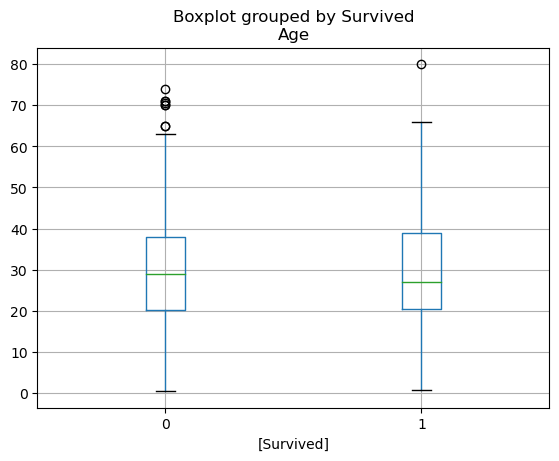

In [23]:
box_and_wisker = dfTitanic.boxplot(column=['Age'], by = ['Survived'])

**Part G** (3 pts) In addition to using boxplots, we can also visualize data using histograms.  
Plot two stacked density histograms showing the distribution of the ages of passengers who survived, and the distribution of the ages of passengers who did not.  
* Use the bin edges $[0,3,6,\ldots,75,78,81]$ for both histograms.
* Include a legend (`plt.legend` after `label=` on the histograms) and label your axes.
* Comment on the results. How would you characterize each distribution? (By _characterize_ we mean that you should indicate whether the data are unimodal, bimodal, multimodal, symmetric, negatively skewed, positively skewed, etc.)  Does your figure suggest that some age ranges are more or less likely to have survived the disaster than other ages? Fully explain your reasoning and use your figure to justify your conclusions.
* If you noticed some relationship between age and likelihood of survival, what is one possible explanation?

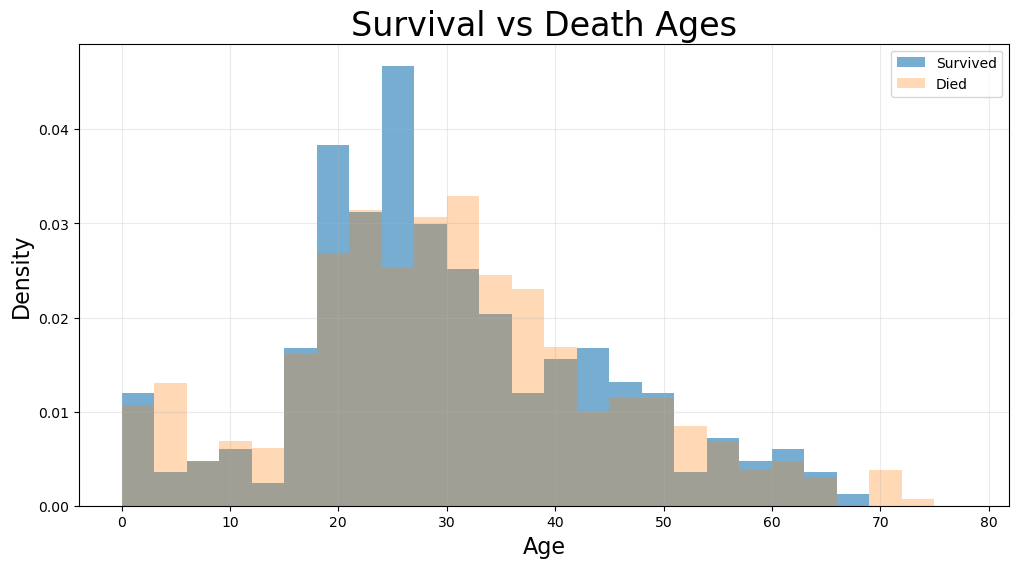

In [24]:
#Plots data
bins = range(0,81,3)
fig, ax = plt.subplots(figsize=(12,6))
dfTitanic.loc[dfTitanic['Survived'] == 1].hist(column="Age", ax=ax, bins=bins, alpha=0.6, label="Survived", density = 1)
dfTitanic.loc[dfTitanic['Survived'] == 0].hist(column="Age", ax=ax, bins=bins, alpha=0.3, label="Died", density = 1)

#Labels graph for better appearence
ax.set_xlabel("Age", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.set_title("Survival vs Death Ages", fontsize=24)
ax.grid(alpha=0.25)

#Create legend
ax.legend();

**Part H: (1 pt)** In Part G, we plotted two *density* histograms, showing the distributions of ages of passengers that survived or did not survive the Titanic disaster. Why would it be misleading for us to have plotted these as *frequency* histograms instead?

A frequency histogram may be misleading because it may show large numbers of surviors at a certain age range without indicating what percentage of the total this is. The denisty histogram shows the groups ages that were more likely to and less likely to survive more clearly as it shows them as a percentage of the whole group.

**Part I** (2 pts) : Do the data suggest class warfare, male chivalry, age bias, or some combination of these characteristics in the final hours aboard the Titanic?  Justify your conclusions based on the computations done above, or do any other analysis that you like, but be sure to clearly justify your conclusions.

First it suggest class warfare because the general survival rate was $39.1$%, however $64.29$% of first class passengers survived in comparison to only $25.18$% of third class passengers. First class passengers were more likely to survive than the general population by a staggering $25.19$%, whereas third class passengers were less likely to survive than the general population by $13.92$%. 

Male chivalry seemed to be an accurate hypothesis as well because men were less likely to survive in every class, with men having a $57.29$% lower chance in first, $74.71$% in second, and $38.76$% in third. Overall, compared to the general survival rate of $39.1$%, females had a survival rate $35.8$% higher and males had a survival rate $19.45$% lower, indicating a strong trend towards male chivalry.

Finally, age bias also seemed absent as the median age of those who lived was $27$ and those who died was $29$ only being two years apart. Additionally both IQR of survivors age and the deads age were with 0.25 years of each other. Thirdly, looking at the density histogram it appears that there is significant overlap between survivors and those who died in all age ranges.


## Final Answers To Selected Problems

These are final answers for selected problems so you can check your work and determine if you are on the right track.  To receive credit on each problem you must show all steps leading to these answers, fully answer the problem, and justify your answer using correct mathematical notation.


1D).  $\frac{n^2+n-2}{2}$

3B).  $39.08\%$

3D iii).  Your code should output 6 different percentages here.  One of these (to check your answer) should be that $13.8\%$ of 3rd class males survived.  

